### Imports

In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb

from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve, auc, precision_recall_curve, auc,	classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay,	confusion_matrix

### Paths and dataset loading

In [ ]:
PROJECT_ROOT = Path.cwd().parent.parent
DATA_PATH = PROJECT_ROOT / "data"

TRAIN_PATH = DATA_PATH / "dvc" / "train_v5.parquet"
TEST_PATH = DATA_PATH / "dvc" / "test_v5.parquet"

# TRAIN_PATH = PROJECT_ROOT / "notebooks" / "troubleshooting" / "df_11_1to12_CM_fraud.csv"
# TEST_PATH = PROJECT_ROOT / "notebooks" / "troubleshooting" / "df_11_13to15_CM_fraud.csv"

train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

Train shape: (314610, 26)
Test shape:  (114190, 26)


### Remove zero-outgoing-call rows and replace 999999

In [ ]:
OUTGOING_COL = "nb_out_calls"
LABEL_COL = "label"

train_df = train_df[
    train_df[OUTGOING_COL] > 10
].copy()

test_df = test_df[
    test_df[OUTGOING_COL] > 10
].copy()

train_df = train_df.replace(999999, 0)
test_df = test_df.replace(999999, 0)

print(f"Train shape after filtering: {train_df.shape}")
print(f"Test shape after filtering:  {test_df.shape}")

Train shape after filtering: (111410, 26)
Test shape after filtering:  (39004, 26)


### Prepare features and target

In [ ]:
DROP_COLS = [
    "label",
    "msisdn",
    "profile_date",
    "nb_distinct_lacs",
    "ratio_distinct_lacs_vs_out"
]

FEATURES = [
    col for col in train_df.columns
    if col not in DROP_COLS
]

X_train = train_df[FEATURES]
y_train = train_df["label"]

X_test = test_df[FEATURES]
y_test = test_df["label"]

print(f"Number of features: {len(FEATURES)}")
print(FEATURES)

Number of features: 21
['nb_out_calls', 'nb_in_calls', 'nb_called_numbers', 'avg_out_duration', 'avg_in_duration', 'ratio_in_vs_out', 'ratio_distinct_vs_out', 'ratio_in_duration_vs_out_duration', 'dawn_count', 'day_count', 'afternoon_count', 'night_count', 'ratio_dawn_vs_out', 'ratio_day_vs_out', 'ratio_afternoon_vs_out', 'ratio_night_vs_out', 'nb_flagged_calls', 'ratio_flagged_vs_out', 'nb_distinct_cell_ids', 'ratio_distinct_cell_ids_vs_out', 'avg_delay_per_day']


### Rows per day

In [5]:
train_rows_per_day = (
    train_df.groupby("profile_date")
    .size()
    .rename("rows")
)

test_rows_per_day = (
    test_df.groupby("profile_date")
    .size()
    .rename("rows")
)

daily_rows = pd.concat(
    [train_rows_per_day, test_rows_per_day],
    axis=1,
    keys=["train_rows", "test_rows"]
).fillna(0).astype(int)

display(daily_rows)

,train_rows,test_rows
profile_date,,
2022-11-01,9306,0
2022-11-02,10050,0
2022-11-03,10058,0
2022-11-04,10642,0
2022-11-05,10599,0
2022-11-06,9075,0
2022-11-07,10620,0
2022-11-08,10478,0
2022-11-09,10286,0


### XGBoost parameters

In [6]:
scale_pos_weight = (
    (y_train == 0).sum()
    /
    (y_train == 1).sum()
)

params = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "eta": 0.05,
    "max_depth": 6,
    "min_child_weight": 1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "gamma": 0,
    "reg_alpha": 0,
    "reg_lambda": 1,
    "scale_pos_weight": scale_pos_weight,
    "seed": 42,
    "n_jobs": -1
}

# use if you want tuned hyperparameters (msisdn grouping)
# params = {
#     "objective": "binary:logistic",
#     "eval_metric": "aucpr",
#     "eta": 0.04679268676711243,
#     "max_depth": 4,
#     "min_child_weight": 10,
#     "gamma": 0.5,
#     "subsample": 0.572249573943548,
#     "colsample_bytree": 0.8979068868124158,
#     "reg_alpha": 5.899704244372543,
#     "reg_lambda": 0.2755180255209402,
#     #"scale_pos_weight": 16.39112801013942,
#     "seed": 42,
#     "n_jobs": -1
# }

# use if you want tuned hyperparameters (am grouping)
# params = {
#     "objective": "binary:logistic",
#     "eval_metric": "aucpr",
#     "eta": 0.061504978294216577,
#     "max_depth": 4,
#     "min_child_weight": 17,
#     "gamma": 0.7950448826199306,
#     "subsample": 0.9612316297503566,
#     "colsample_bytree": 0.6450748029091332,
#     "reg_alpha": 8.787729095874198,
#     "reg_lambda": 9.75774664145889,
#     "scale_pos_weight": 16.353963263279827,
#     "seed": 42,
#     "n_jobs": -1
# }

NUM_BOOST_ROUND = 300

print(f"scale_pos_weight: {scale_pos_weight:.4f}")

scale_pos_weight: 13.3219


### Stratified K-Fold cross-validation

In [7]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=False
)

oof_proba = np.zeros(len(X_train))

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_train, y_train),
    start=1
):
    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]

    X_fold_val = X_train.iloc[val_idx]
    y_fold_val = y_train.iloc[val_idx]

    fold_scale_pos_weight = (
        (y_fold_train == 0).sum()
        /
        (y_fold_train == 1).sum()
    )

    fold_params = params.copy()
    fold_params["scale_pos_weight"] = fold_scale_pos_weight

    model = xgb.train(
        params=fold_params,
        dtrain=xgb.DMatrix(
            X_fold_train,
            label=y_fold_train
        ),
        num_boost_round=NUM_BOOST_ROUND
    )

    oof_proba[val_idx] = model.predict(
        xgb.DMatrix(X_fold_val)
    )

    precision, recall, _ = precision_recall_curve(
        y_fold_val,
        oof_proba[val_idx]
    )

    fold_pr_auc = auc(
        recall,
        precision
    )

    print(
        f"Fold {fold}: "
        f"train={len(train_idx):,}, "
        f"validation={len(val_idx):,}, "
        f"PR-AUC={fold_pr_auc:.6f}"
    )

Fold 1: train=89,128, validation=22,282, PR-AUC=0.673805
Fold 2: train=89,128, validation=22,282, PR-AUC=0.672177
Fold 3: train=89,128, validation=22,282, PR-AUC=0.644703
Fold 4: train=89,128, validation=22,282, PR-AUC=0.665942
Fold 5: train=89,128, validation=22,282, PR-AUC=0.694423


### Overall OOF PR-AUC

In [8]:
precision_oof, recall_oof, _ = precision_recall_curve(
    y_train,
    oof_proba
)

oof_pr_auc = auc(
    recall_oof,
    precision_oof
)

print(f"Overall OOF PR-AUC: {oof_pr_auc:.6f}")

Overall OOF PR-AUC: 0.670043


### Threshold tuning

In [9]:
precision_oof, recall_oof, thresholds_oof = precision_recall_curve(
    y_train,
    oof_proba
)

# Calculate F1 for every available threshold
f1_scores = (
    2 * precision_oof[:-1] * recall_oof[:-1]
    / (precision_oof[:-1] + recall_oof[:-1] + 1e-12)
)

best_idx = f1_scores.argmax()

best_threshold = thresholds_oof[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best OOF threshold: {best_threshold:.6f}")
print(f"Best OOF F1-score:  {best_f1:.6f}")
print(f"OOF Precision:      {precision_oof[best_idx]:.6f}")
print(f"OOF Recall:         {recall_oof[best_idx]:.6f}")

Best OOF threshold: 0.849486
Best OOF F1-score:  0.588715
OOF Precision:      0.733691
OOF Recall:         0.491580


### Train final model on all training data

In [10]:
final_model = xgb.train(
    params=params,
    dtrain=xgb.DMatrix(
        X_train,
        label=y_train
    ),
    num_boost_round=NUM_BOOST_ROUND
)

### Evaluate on test set

Test PR-AUC: 0.674223

Threshold used: 0.849486

Classification Report:
              precision    recall  f1-score   support

           0     0.9631    0.9856    0.9742     36288
           1     0.7199    0.4959    0.5873      2716

    accuracy                         0.9515     39004
   macro avg     0.8415    0.7408    0.7808     39004
weighted avg     0.9462    0.9515    0.9473     39004



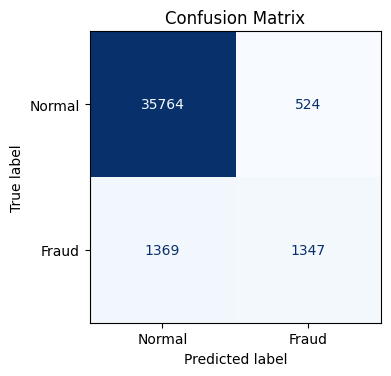

In [11]:
test_proba = final_model.predict(
    xgb.DMatrix(X_test)
)

# Test PR-AUC — threshold independent
precision_test, recall_test, _ = precision_recall_curve(
    y_test,
    test_proba
)

test_pr_auc = auc(
    recall_test,
    precision_test
)

print(f"Test PR-AUC: {test_pr_auc:.6f}")

# Apply threshold selected using OOF predictions
test_pred = (
    test_proba >= best_threshold
).astype(int)

print(f"\nThreshold used: {best_threshold:.6f}")

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_pred,
        digits=4
    )
)

# Confusion matrix
cm = confusion_matrix(y_test, test_pred)

fig, ax = plt.subplots(figsize=(4, 4))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraud"]
).plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### Final comparison

In [12]:
comparison = pd.DataFrame({
    "dataset": ["Training OOF", "Test"],
    "pr_auc": [oof_pr_auc, test_pr_auc]
})

display(
    comparison.style.format({
        "pr_auc": "{:.6f}"
    })
)

,dataset,pr_auc
0,Training OOF,0.670043
1,Test,0.674223
